# Growth Function Estimation — Soft-DTW Balls

The **growth function** (a.k.a. shatter function) of a hypothesis class $\mathcal{H}$ is:

$$\Pi_\mathcal{H}(s) \;=\; \max_{\,S \subseteq \mathcal{X},\;|S|=s} \bigl|\{I \subseteq S : \exists\, B \in \mathcal{H},\; B \cap S = I\}\bigr|$$

Here $\mathcal{H}$ is the class of Soft-DTW balls with **fixed** center complexity $k$ operating on query series in $\mathbb{R}^m$.  The growth function is a function of the **sample size** $s$, not of $m$.

**Estimation procedure** (for a fixed $m, k$):

1. Fix `m` and set `k = m`.
2. For each sample size $s = 1, 2, \ldots, S_{\max}$:
   - Draw several random sets $S = \{Q_1, \ldots, Q_s\}$ with each $Q_i \in \mathbb{R}^m$.
   - Test **all** $2^s$ subsets $I \subseteq S$ — unlike `check_shattering`, do **not** short-circuit on the first failure.
   - Record $\hat\Pi_\mathcal{H}(s) = \max_{\text{samples}} \#\{\text{realizable subsets}\}$ as a lower-bound estimate.

**Reference bounds**

| Bound | Formula |
|---|---|
| Full shattering | $\Pi_\mathcal{H}(s) = 2^s$ (if $s \leq d_\text{VC}$) |
| Sauer–Shelah | $\Pi_\mathcal{H}(s) \leq \sum_{i=0}^{d_\text{VC}} \binom{s}{i}$ (for $s > d_\text{VC}$) |

> ⚠️ Each $s$ requires $2^s$ optimisation calls per sample. Keep `S_MAX ≤ 7` unless you have a large time budget.


## 1 · Imports & Configuration


In [5]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("soft_dtw_solver.py")))

import itertools
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from math import comb

from soft_dtw_solver import optimize_ball_robust, to_1d_numpy, _sample_query_series, ProjectedRuntimeExceeded

# ── Hypothesis class (fixed) ──────────────────────────────────────────────────
M                  = 3     # length / dimensionality of each query series Q ∈ ℝ^m
K                  = M     # centre length k = m

# ── Growth function sweep ─────────────────────────────────────────────────────
S_VALUES           = np.arange(1, 12)   # sample sizes s = 1 … 15

NUM_SAMPLES        = 3     # independent random point sets per s
                           # (2^15 = 32 768 subsets at s=15 — keep this low)

# ── Solver hyperparameters ────────────────────────────────────────────────────
GAMMA              = 0.1   # Soft-DTW smoothing parameter
EPOCHS             = 500   # gradient steps per optimisation call
RETRIES            = 5     # restarts per subset
VALIDATION         = True  # require hard-DTW strict separation

# ── Runtime guard ─────────────────────────────────────────────────────────────
# If the first subset in a sample already projects the full 2^s pass beyond
# this budget, the sample is aborted and its count is recorded as None.
# Set to None to disable.
MAX_PROJECTED_SECONDS = 3 * 3600   # 3 h per (s, sample) pair

# ── Sampling ──────────────────────────────────────────────────────────────────
SAMPLING_MODE         = "near_unit_sphere"
SAMPLING_RADIUS_NOISE = 0.05

# ── Sauer–Shelah reference (optional) ────────────────────────────────────────
D_VC_ESTIMATE      = None  # e.g. set from sequential-capacity results for m=7

# ── Rough runtime estimate ────────────────────────────────────────────────────
print("Configuration loaded.")
print(f"  m (fixed)    : {M}")
print(f"  k (fixed)    : {K}")
print(f"  S_VALUES     : {S_VALUES}")
print(f"  NUM_SAMPLES  : {NUM_SAMPLES}")
print(f"  SAMPLING     : {SAMPLING_MODE}  (noise={SAMPLING_RADIUS_NOISE})")
print(f"  time guard   : {MAX_PROJECTED_SECONDS / 3600:.1f} h per (s, sample)")
print()
print("  Subset counts per sample:")
for s in S_VALUES:
    print(f"    s={s:2d} → {2**s:6d} subsets")


Configuration loaded.
  m (fixed)    : 3
  k (fixed)    : 3
  S_VALUES     : [ 1  2  3  4  5  6  7  8  9 10 11]
  NUM_SAMPLES  : 3
  SAMPLING     : near_unit_sphere  (noise=0.05)
  time guard   : 3.0 h per (s, sample)

  Subset counts per sample:
    s= 1 →      2 subsets
    s= 2 →      4 subsets
    s= 3 →      8 subsets
    s= 4 →     16 subsets
    s= 5 →     32 subsets
    s= 6 →     64 subsets
    s= 7 →    128 subsets
    s= 8 →    256 subsets
    s= 9 →    512 subsets
    s=10 →   1024 subsets
    s=11 →   2048 subsets


## 2 · `count_realizable_subsets` — non-short-circuiting shattering count

Unlike `check_shattering`, which returns `False` as soon as one subset fails, this function tests **every** $2^m$ subset and counts how many can be separated.  It returns both the count and the dict of successful witnesses.


In [6]:
def count_realizable_subsets(
    Qs,
    k: int,
    gamma: float = 1.0,
    epochs: int = 200,
    retries: int = 5,
    validation: bool = True,
    verbose: bool = False,
    max_projected_seconds: float | None = None,
) -> tuple[int | None, dict]:
    """
    Count how many of the 2^|Qs| subsets of *Qs* can be realised by a
    Soft-DTW ball with centre complexity *k*.

    Unlike ``check_shattering``, this does NOT short-circuit on failure;
    every subset is tried.  Raises ``ProjectedRuntimeExceeded`` if the
    first subset's elapsed time already projects the full pass beyond
    ``max_projected_seconds``.

    Returns
    -------
    n_realizable : int   — number of subsets successfully separated.
    witnesses    : dict  — {tuple(subset_I) -> witness_info} for successes.
    """
    indices       = list(range(len(Qs)))
    witnesses     = {}
    total_subsets = 2 ** len(Qs)
    first_subset  = True

    for r in range(len(Qs) + 1):
        for subset_I in itertools.combinations(indices, r):
            I_list = list(subset_I)

            t_sub = time.perf_counter()
            success, P_opt, Delta_opt, max_in_dtw, min_out_dtw, hard_valid = optimize_ball_robust(
                Qs,
                I_list,
                k,
                gamma=gamma,
                epochs=epochs,
                retries=retries,
                require_hard_dtw_validation=validation,
                verbose=False,
            )
            sub_elapsed = time.perf_counter() - t_sub

            # ── Runtime guard: check after the very first subset ──────────
            if first_subset and max_projected_seconds is not None:
                projected = sub_elapsed * total_subsets
                if projected > max_projected_seconds:
                    raise ProjectedRuntimeExceeded(
                        f"Projected runtime {projected / 3600:.2f} h "
                        f"({total_subsets} subsets × {sub_elapsed:.2f}s) "
                        f"exceeds limit of {max_projected_seconds / 3600:.2f} h."
                    )
            first_subset = False

            if success:
                witnesses[tuple(I_list)] = {
                    "P":              to_1d_numpy(P_opt),
                    "Delta":          float(Delta_opt.item()
                                            if isinstance(Delta_opt, torch.Tensor)
                                            else Delta_opt),
                    "max_in_dtw":     max_in_dtw,
                    "min_out_dtw":    min_out_dtw,
                    "hard_dtw_valid": bool(hard_valid),
                }
            if verbose:
                tick = "✓" if success else "✗"
                print(f"  {tick}  I={list(I_list)}")

    n_realizable = len(witnesses)
    if verbose:
        print(f"\n  → {n_realizable} / {total_subsets} subsets realizable "
              f"({'fully shattered' if n_realizable == total_subsets else 'partial'})")
    return n_realizable, witnesses


print("count_realizable_subsets defined.")


count_realizable_subsets defined.


## 3 · Estimate the Growth Function

For each sample size $s$, we draw `NUM_SAMPLES` random sets $S = \{Q_1, \ldots, Q_s\} \subset \mathbb{R}^m$ (with $m$ and $k$ fixed), count the realizable subsets in each, and keep:

- **`pi_hat`** — the sample-maximum $\hat\Pi_\mathcal{H}(s)$ (lower bound),
- **`mean_count`** / **`std_count`** — distribution across random draws,
- **`frac_max`** — $\hat\Pi_\mathcal{H}(s) / 2^s$ (fraction of all labelings covered).

> ⚠️ Each $s$ requires $2^s$ optimisations per sample: $s=6$ → 64 calls, $s=8$ → 256 calls.


In [7]:
results = []   # list of dicts, one per sample size s

for s in S_VALUES:
    total_subsets = 2 ** s

    print(f"\n{'='*60}")
    print(f"  s = {s}   ({total_subsets} subsets per sample,  m={M}, k={K})")
    print(f"{'='*60}")

    counts    = []   # n_realizable per successful sample (None = aborted)
    t_start_s = time.time()

    for sample_idx in range(NUM_SAMPLES):
        # ── Draw s random query series, each in ℝ^m ──────────────────────
        Qs = [
            _sample_query_series(M, SAMPLING_MODE, SAMPLING_RADIUS_NOISE)
            for _ in range(s)
        ]

        t0 = time.time()
        try:
            n_realizable, _ = count_realizable_subsets(
                Qs, K,
                gamma=GAMMA,
                epochs=EPOCHS,
                retries=RETRIES,
                validation=VALIDATION,
                verbose=False,
                max_projected_seconds=MAX_PROJECTED_SECONDS,
            )
            elapsed = time.time() - t0
            counts.append(n_realizable)
            print(
                f"  sample {sample_idx + 1:2d}/{NUM_SAMPLES} : "
                f"{n_realizable:6d} / {total_subsets}  "
                f"({100 * n_realizable / total_subsets:.1f}%)  "
                f"[{elapsed:.1f}s]"
            )
        except ProjectedRuntimeExceeded as exc:
            elapsed = time.time() - t0
            counts.append(None)
            print(f"  sample {sample_idx + 1:2d}/{NUM_SAMPLES} : ABORTED — {exc}  [{elapsed:.1f}s]")

    elapsed_s = time.time() - t_start_s

    valid_counts = [c for c in counts if c is not None]
    pi_hat       = int(max(valid_counts)) if valid_counts else None
    results.append({
        "s":                   s,
        "m":                   M,
        "k":                   K,
        "2^s":                 total_subsets,
        "pi_hat":              pi_hat,
        "mean_count":          float(np.mean(valid_counts))  if valid_counts else float("nan"),
        "std_count":           float(np.std(valid_counts))   if valid_counts else float("nan"),
        "min_count":           int(min(valid_counts))        if valid_counts else None,
        "all_counts":          counts,
        "frac_max":            pi_hat / total_subsets        if pi_hat is not None else float("nan"),
        "elapsed_s":           elapsed_s,
        "n_aborted":           counts.count(None),
        "fully_shattered_any": (pi_hat == total_subsets)     if pi_hat is not None else False,
    })

    status = (
        "FULLY SHATTERED ✓" if results[-1]["fully_shattered_any"]
        else f"{pi_hat} / {total_subsets}" if pi_hat is not None
        else "all aborted"
    )
    print(
        f"  → Pi_hat(s={s}) = {status}   "
        f"[aborted: {results[-1]['n_aborted']}/{NUM_SAMPLES}]   "
        f"total {elapsed_s:.0f}s"
    )

print(f"\n\n{'='*60}")
print("  Growth function estimation complete.")
print(f"{'='*60}")



  s = 1   (2 subsets per sample,  m=3, k=3)
  sample  1/3 :      2 / 2  (100.0%)  [0.4s]
  sample  2/3 :      2 / 2  (100.0%)  [0.4s]
  sample  3/3 :      2 / 2  (100.0%)  [0.4s]
  → Pi_hat(s=1) = FULLY SHATTERED ✓   [aborted: 0/3]   total 1s

  s = 2   (4 subsets per sample,  m=3, k=3)
  sample  1/3 :      4 / 4  (100.0%)  [1.5s]
  sample  2/3 :      4 / 4  (100.0%)  [1.5s]
  sample  3/3 :      4 / 4  (100.0%)  [1.5s]
  → Pi_hat(s=2) = FULLY SHATTERED ✓   [aborted: 0/3]   total 5s

  s = 3   (8 subsets per sample,  m=3, k=3)
  sample  1/3 :      8 / 8  (100.0%)  [4.2s]
  sample  2/3 :      8 / 8  (100.0%)  [4.3s]
  sample  3/3 :      8 / 8  (100.0%)  [4.3s]
  → Pi_hat(s=3) = FULLY SHATTERED ✓   [aborted: 0/3]   total 13s

  s = 4   (16 subsets per sample,  m=3, k=3)
  sample  1/3 :     16 / 16  (100.0%)  [11.3s]
  sample  2/3 :     15 / 16  (93.8%)  [14.0s]
  sample  3/3 :     16 / 16  (100.0%)  [14.6s]
  → Pi_hat(s=4) = FULLY SHATTERED ✓   [aborted: 0/3]   total 40s

  s = 5   (32 s

KeyboardInterrupt: 

## 4 · Results Table


In [ ]:
def _fmt(val, fmt=".1f"):
    return f"{val:{fmt}}" if val is not None and not (isinstance(val, float) and np.isnan(val)) else "—"

df = pd.DataFrame([
    {
        "s":              r["s"],
        "2^s":            r["2^s"],
        "Pi_hat(s)":      r["pi_hat"] if r["pi_hat"] is not None else "—",
        "mean":           _fmt(r["mean_count"]),
        "std":            _fmt(r["std_count"]),
        "min":            r["min_count"] if r["min_count"] is not None else "—",
        "coverage (%)":   _fmt(100 * r["frac_max"]) if not np.isnan(r["frac_max"]) else "—",
        "shattered?":     "✓" if r["fully_shattered_any"] else "✗",
        "aborted":        f"{r['n_aborted']}/{NUM_SAMPLES}",
        "time (s)":       _fmt(r["elapsed_s"], ".0f"),
    }
    for r in results
])

print(df.to_string(index=False))


 s  m (fixed)  k (fixed)  2^s  Pi_hat(s)  mean std  min coverage (%) shattered? time (s)
 1          4          4    2          2   2.0 0.0    2        100.0          ✓        1
 2          4          4    4          4   4.0 0.0    4        100.0          ✓        5
 3          4          4    8          8   8.0 0.0    8        100.0          ✓       15
 4          4          4   16         16  16.0 0.0   16        100.0          ✓       40
 5          4          4   32         32  32.0 0.0   32        100.0          ✓      103
 6          4          4   64         64  63.5 0.5   63        100.0          ✓      277
 7          4          4  128        118 112.0 6.0  106         92.2          ✗    11289


## 5 · Visualisation

### 5a — Growth function vs $2^m$ and Sauer–Shelah bound

The left panel shows absolute counts; the right panel shows the fraction $\hat\Pi_\mathcal{H}(m)/2^m$.

If `D_VC_ESTIMATE` is set, the Sauer–Shelah polynomial bound $\sum_{i=0}^{d_\text{VC}} \binom{m}{i}$ is overlaid.


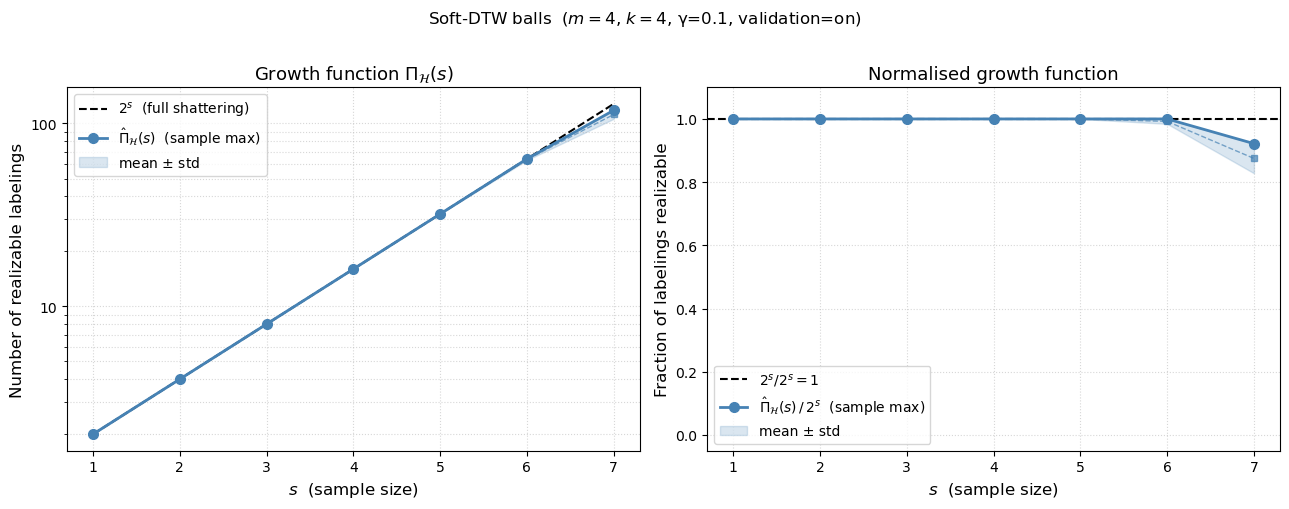

In [ ]:
def sauer_shelah(s_vals, d_vc):
    """Sum_{i=0}^{d_vc} C(s, i), capped at 2^s."""
    return [min(sum(comb(s, i) for i in range(d_vc + 1)), 2**s) for s in s_vals]


s_vals       = [r["s"]          for r in results]
pi_hat_vals  = [r["pi_hat"]     for r in results]
mean_vals    = [r["mean_count"] for r in results]
std_vals     = [r["std_count"]  for r in results]
two_pow_s    = [r["2^s"]        for r in results]
frac_vals    = [r["frac_max"]   for r in results]
frac_mean    = [r["mean_count"] / r["2^s"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: absolute counts ─────────────────────────────────────────────────────
ax = axes[0]
ax.semilogy(s_vals, two_pow_s, "k--", linewidth=1.5, label=r"$2^s$  (full shattering)")
ax.semilogy(s_vals, pi_hat_vals, "o-", color="steelblue", linewidth=2,
            markersize=7, label=r"$\hat\Pi_\mathcal{H}(s)$  (sample max)")
ax.fill_between(
    s_vals,
    [mu - std for mu, std in zip(mean_vals, std_vals)],
    [mu + std for mu, std in zip(mean_vals, std_vals)],
    color="steelblue", alpha=0.2, label=r"mean $\pm$ std",
)
ax.plot(s_vals, mean_vals, "s--", color="steelblue", linewidth=1,
        markersize=5, alpha=0.7)

if D_VC_ESTIMATE is not None:
    ss_vals = sauer_shelah(s_vals, D_VC_ESTIMATE)
    ax.semilogy(s_vals, ss_vals, "^--", color="tomato", linewidth=1.5,
                markersize=6, label=f"Sauer–Shelah  ($d_{{VC}}={D_VC_ESTIMATE}$)")

ax.set_xlabel("$s$  (sample size)", fontsize=12)
ax.set_ylabel("Number of realizable labelings", fontsize=12)
ax.set_title(r"Growth function $\Pi_\mathcal{H}(s)$", fontsize=13)
ax.set_xticks(s_vals)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle=":", alpha=0.5)

# ── Right: normalised fraction ────────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(1.0, color="k", linestyle="--", linewidth=1.5, label=r"$2^s / 2^s = 1$")
ax2.plot(s_vals, frac_vals, "o-", color="steelblue", linewidth=2,
         markersize=7, label=r"$\hat\Pi_\mathcal{H}(s) \,/\, 2^s$  (sample max)")
ax2.fill_between(
    s_vals,
    [mu - std / r["2^s"] for mu, std, r in zip(frac_mean, std_vals, results)],
    [min(1.0, mu + std / r["2^s"]) for mu, std, r in zip(frac_mean, std_vals, results)],
    color="steelblue", alpha=0.2, label="mean ± std",
)
ax2.plot(s_vals, frac_mean, "s--", color="steelblue", linewidth=1,
         markersize=5, alpha=0.7)

if D_VC_ESTIMATE is not None:
    ss_frac = [ss / tp for ss, tp in zip(sauer_shelah(s_vals, D_VC_ESTIMATE), two_pow_s)]
    ax2.plot(s_vals, ss_frac, "^--", color="tomato", linewidth=1.5,
             markersize=6, label=f"Sauer–Shelah  ($d_{{VC}}={D_VC_ESTIMATE}$)")

ax2.set_xlabel("$s$  (sample size)", fontsize=12)
ax2.set_ylabel(r"Fraction of labelings realizable", fontsize=12)
ax2.set_title(r"Normalised growth function", fontsize=13)
ax2.set_xticks(s_vals)
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.5)

fig.suptitle(
    f"Soft-DTW balls  ($m={M}$, $k={K}$, "
    f"γ={GAMMA}, validation={'on' if VALIDATION else 'off'})",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


### 5b — Per-sample count distribution (box plot)

Shows the spread of counts across the `NUM_SAMPLES` random draws for each $m$.


/var/folders/qc/gl6rlk253fs0zbvjtf9kjsmw0000gn/T/ipykernel_78308/2539322967.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(


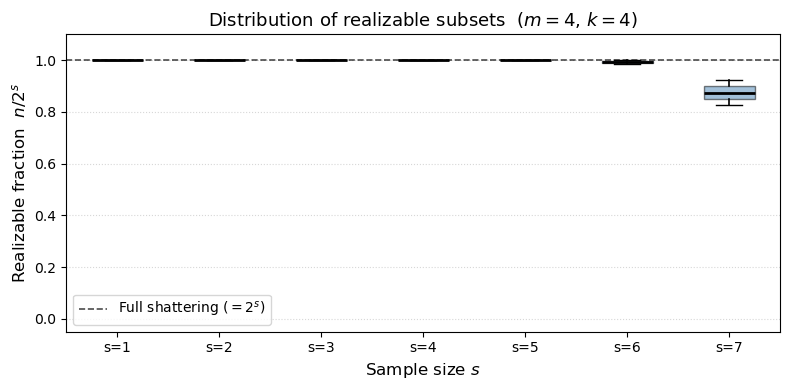

In [ ]:
fig2, ax3 = plt.subplots(figsize=(8, 4))

# Normalise counts to fractions for comparability across s
frac_data = [[c / r["2^s"] for c in r["all_counts"]] for r in results]
labels    = [f"s={r['s']}" for r in results]

ax3.boxplot(
    frac_data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=4, alpha=0.6),
)
ax3.axhline(1.0, color="k", linestyle="--", linewidth=1.2, alpha=0.7,
            label=r"Full shattering ($= 2^s$)")
ax3.set_ylabel(r"Realizable fraction  $n / 2^s$", fontsize=12)
ax3.set_xlabel("Sample size $s$", fontsize=12)
ax3.set_title(
    rf"Distribution of realizable subsets  ($m={M}$, $k={K}$)",
    fontsize=13,
)
ax3.set_ylim(-0.05, 1.1)
ax3.legend(fontsize=10)
ax3.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


## 6 · Save Results to CSV

Persist the summary table so results can be compared across runs (e.g. different $k$, `gamma`, or sampling modes).


In [ ]:
import csv, datetime

out_csv = "growth_function_results.csv"

fieldnames = [
    "s", "m", "k", "2^s",
    "pi_hat", "mean_count", "std_count", "min_count",
    "frac_max", "fully_shattered_any",
    "all_counts",
    "gamma", "epochs", "retries", "validation",
    "sampling_mode", "sampling_radius_noise",
    "num_samples", "timestamp",
]

timestamp = datetime.datetime.now().isoformat(timespec="seconds")

with open(out_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in results:
        writer.writerow({
            "s":                    r["s"],
            "m":                    r["m"],
            "k":                    r["k"],
            "2^s":                  r["2^s"],
            "pi_hat":               r["pi_hat"],
            "mean_count":           round(r["mean_count"], 4),
            "std_count":            round(r["std_count"],  4),
            "min_count":            r["min_count"],
            "frac_max":             round(r["frac_max"], 6),
            "fully_shattered_any":  int(r["fully_shattered_any"]),
            "all_counts":           ";".join(map(str, r["all_counts"])),
            "gamma":                GAMMA,
            "epochs":               EPOCHS,
            "retries":              RETRIES,
            "validation":           int(VALIDATION),
            "sampling_mode":        SAMPLING_MODE,
            "sampling_radius_noise": SAMPLING_RADIUS_NOISE,
            "num_samples":          NUM_SAMPLES,
            "timestamp":            timestamp,
        })

print(f"Results saved to: {out_csv}")


Results saved to: growth_function_results.csv
